# 06 — Longer Forecast Horizons

Notebook 05 produced an uncomfortable result: the XGBoost baseline did not beat
**persistence** — the trivial rule "assume the link is still in whatever class it
was in at the last reading". Persistence won on three folds and tied on two.

The diagnosis was that the task was framed too easily. Predicting congestion five
minutes ahead on a series that barely moves in five minutes is nearly free, so
there is nothing left for a model to add.

**This notebook tests that diagnosis.** Same features, same folds, same model
settings — the *only* thing that changes is how far ahead we predict.

If the diagnosis is right, persistence should decay as the horizon grows, and the
model should overtake it somewhere. If the model still loses at 30 minutes, that is
a real finding and we report it as one rather than reaching for more features.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

PROJECT = Path.cwd().parent
PROCESSED = PROJECT / "data" / "processed"

CLASSES = ["Low", "Medium", "High", "Critical"]

features = pd.read_parquet(PROCESSED / "abilene_features.parquet")
fold_days = pd.read_csv(PROCESSED / "cv_folds.csv", parse_dates=["day"])
fold_thresholds = pd.read_csv(PROCESSED / "cv_fold_thresholds.csv")
features["day"] = features["timestamp"].dt.normalize()

pd.set_option("display.width", 210)
print(f"features: {features.shape[0]:,} rows")

features: 1,442,880 rows


In [2]:
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#c3c2b7"
INK, MUTED = "#0b0b0b", "#898781"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "font.size": 9, "legend.frameon": False,
})
print("style set")

style set


## Step 1 — What "horizon" means here, precisely

This needs stating carefully or the three horizons are not comparable.

The feature row stamped at time *t* was built in notebook 02 from **data up to
*t − 5 min***: `lag_1` is the reading five minutes ago, and the rolling windows are
all shifted by one step so a row never contains its own value.

So the newest information the model ever has is from *t − 5 min*. We therefore
define the horizon as:

> **lead time = the gap between the newest data the model can see and the moment
> being predicted.**

Under that definition:

| Lead time | Predict the label at | Steps to shift the target |
|---|---|---|
| 5 min *(notebook 05)* | *t* | 0 |
| **15 min** | *t + 10 min* | 2 |
| **30 min** | *t + 25 min* | 5 |

This keeps "5 minutes of warning", "15 minutes of warning" and "30 minutes of
warning" meaning the same kind of thing, which is what makes the comparison honest.

**The shift must be gap-aware.** Shifting the target by rows would pair a Tuesday
with a reading 18 days later across a data gap. We shift on the complete 5-minute
grid — the same `.asfreq("5min")` trick as notebook 02 — so a target that would
land in a gap comes out missing and the row is dropped.

In [3]:
# Utilisation on the regular grid, so shifting means real elapsed time.
utilisation = features.pivot(index="timestamp", columns="link",
                             values="utilization_pct")
grid = utilisation.asfreq("5min")

HORIZONS = {5: 0, 15: 2, 30: 5}      # lead time in minutes -> steps to shift

future = {}
for lead, steps in HORIZONS.items():
    # shift(-steps) brings a LATER value back to this row = what we must predict.
    shifted = grid.shift(-steps).loc[utilisation.index]
    future[lead] = (shifted.stack(future_stack=True)
                    .reindex(pd.MultiIndex.from_arrays(
                        [features["timestamp"], features["link"]]))
                    .to_numpy())
    missing = np.isnan(future[lead]).sum()
    print(f"lead {lead:>2} min: {missing:>7,} rows have no target "
          f"({missing / len(features) * 100:.2f}%) - target falls in a gap "
          "or past the end")

lead  5 min:       0 rows have no target (0.00%) - target falls in a gap or past the end


lead 15 min:     300 rows have no target (0.02%) - target falls in a gap or past the end


lead 30 min:     750 rows have no target (0.05%) - target falls in a gap or past the end


The number of unusable rows grows with the horizon, as it should: the further ahead
you look, the more often the answer falls into a data gap or past the end of the
series. Those rows are dropped rather than filled.

## Step 1b — A correction: the clock features must point at the target

There is a subtlety here that is easy to get wrong, and the first version of this
notebook got it wrong.

The features fall into two kinds:

- **Lags and rolling statistics** describe *what has already happened*. They must
  be anchored to the newest data available at prediction time. Correct as built.
- **Hour-of-day and day-of-week** describe *the moment being predicted*. The clock
  is knowable arbitrarily far in advance — at 14:00 you already know that 30
  minutes from now will be 14:30 on the same Tuesday. Using the target's clock
  reading is therefore legitimate, not leakage.

Notebook 02 built the cyclical features from each row's **own** timestamp, which is
correct when predicting time *t* (the 5-minute case, where the target *is* *t*).
But for the 15- and 30-minute horizons the target sits 10 and 25 minutes later, so
carrying those features over unchanged tells the model the wrong time of day — by
a margin that grows with the horizon.

That is exactly the shape that could manufacture a widening gap on its own, so it
is fixed before drawing any conclusion about persistence. The cyclical features are
recomputed from the **target** timestamp for each horizon.

## Step 2 — Building each fold, for a given horizon

Identical to notebook 05 except the target now comes from the future value, the
clock features are re-anchored to the target time, and rows without a target are
removed.

**The persistence baseline is recomputed for each horizon.** The prediction itself
is unchanged — it is always "the class at the last reading", i.e. `lag_1` — but it
is now scored against a target further away. That is precisely what should make it
degrade, and it is why the baseline cannot be carried over from notebook 05.

In [4]:
FEATURE_COLUMNS = [c for c in features.columns
                   if c not in ("timestamp", "link", "utilization_pct",
                                "congestion", "day")]
LINK_ORDER = sorted(features["link"].unique())
CYCLICAL = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]


def cyclical_at(timestamps):
    """Sine/cosine clock features for whatever moment we are asked about."""
    hours = timestamps.dt.hour + timestamps.dt.minute / 60
    days = timestamps.dt.dayofweek + hours / 24
    return pd.DataFrame({
        "hour_sin": np.sin(2 * np.pi * hours / 24),
        "hour_cos": np.cos(2 * np.pi * hours / 24),
        "dow_sin": np.sin(2 * np.pi * days / 7),
        "dow_cos": np.cos(2 * np.pi * days / 7),
    }, index=timestamps.index)


# How big is the error being corrected?
sample = features["timestamp"].head(1)
print(f"for a row stamped {sample.iloc[0]}:")
for lead, steps in HORIZONS.items():
    target_time = sample + pd.Timedelta(minutes=5 * steps)
    at_t = cyclical_at(sample)["hour_sin"].iloc[0]
    at_target = cyclical_at(target_time)["hour_sin"].iloc[0]
    print(f"  lead {lead:>2} min -> target {target_time.iloc[0]:%H:%M}   "
          f"hour_sin at t {at_t:+.4f} vs at target {at_target:+.4f}   "
          f"(off by {abs(at_target - at_t):.4f})")
print("\nAt 5 min the target IS t, so nothing changes there and the notebook 05")
print("baseline remains directly comparable.")


def classify(values, links, cuts):
    """Turn utilisation values into class codes using one fold's thresholds."""
    return ((values > links.map(cuts["p50"]).to_numpy()).astype(int)
            + (values > links.map(cuts["p80"]).to_numpy()).astype(int)
            + (values > links.map(cuts["p95"]).to_numpy()).astype(int))


def build_fold(fold_number, lead):
    days = fold_days[fold_days.fold == fold_number]
    train_days = set(days[days.part == "train"].day)
    test_days = set(days[days.part == "test"].day)
    cuts = fold_thresholds[fold_thresholds.fold == fold_number].set_index("link")

    target = future[lead]

    def prepare(day_set):
        mask = features.day.isin(day_set).to_numpy() & ~np.isnan(target)
        block = features[mask]
        y = classify(target[mask], block["link"], cuts)
        X = block[FEATURE_COLUMNS].copy()
        X["link"] = pd.Categorical(block["link"], categories=LINK_ORDER)
        # Re-anchor the clock features to the moment being predicted, not to t.
        target_time = block["timestamp"] + pd.Timedelta(minutes=5 * HORIZONS[lead])
        X[CYCLICAL] = cyclical_at(target_time).to_numpy().astype("float32")
        # Persistence: the class at the most recent reading the model has (lag_1).
        persistence = classify(block["lag_1"].to_numpy(), block["link"], cuts)
        persistence = np.where(block["lag_1"].isna().to_numpy(), 0, persistence)
        return X, y, persistence

    X_train, y_train, _ = prepare(train_days)
    X_test, y_test, persistence = prepare(test_days)
    return X_train, y_train, X_test, y_test, persistence


def make_model():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        tree_method="hist", enable_categorical=True,
        objective="multi:softmax", num_class=len(CLASSES),
        n_jobs=-1, random_state=42,
    )


X_tr, y_tr, X_te, y_te, pers = build_fold(1, 15)
print(f"fold 1 @ 15 min -> train {X_tr.shape}, test {X_te.shape}")
print(f"model settings unchanged from notebook 05: "
      f"{make_model().n_estimators} trees, depth {make_model().max_depth}")

for a row stamped 2004-03-01 00:00:00:
  lead  5 min -> target 00:00   hour_sin at t +0.0000 vs at target +0.0000   (off by 0.0000)
  lead 15 min -> target 00:10   hour_sin at t +0.0000 vs at target +0.0436   (off by 0.0436)
  lead 30 min -> target 00:25   hour_sin at t +0.0000 vs at target +0.1089   (off by 0.1089)

At 5 min the target IS t, so nothing changes there and the notebook 05
baseline remains directly comparable.


fold 1 @ 15 min -> train (276360, 17), test (233220, 17)
model settings unchanged from notebook 05: 200 trees, depth 6


## Step 3 — Train both horizons across all five folds

Ten fits in total. Everything except the target is held fixed.

In [5]:
import datetime

# Long job: append a line per fit to a log file as well as printing, so progress
# is visible from outside while the notebook is still running.
LOG = PROJECT / "logs" / "nb06_progress.log"
LOG.parent.mkdir(exist_ok=True)


def log(message):
    stamp = datetime.datetime.now().strftime("%H:%M:%S")
    with open(LOG, "a") as handle:
        print(f"{stamp}  {message}", file=handle)
    print(message)


records = []
per_class_records = []
confusions = {}

log(f"=== training run started, {len(list((15, 30))) * 5} fits ===")

for lead in (15, 30):
    for fold_number in sorted(fold_days.fold.unique()):
        X_train, y_train, X_test, y_test, persistence = build_fold(fold_number, lead)

        model = make_model()
        model.fit(X_train, y_train,
                  sample_weight=compute_sample_weight("balanced", y_train))
        predictions = model.predict(X_test)

        majority = np.bincount(y_train, minlength=len(CLASSES)).argmax()
        naive = np.full_like(y_test, majority)

        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, predictions, labels=range(len(CLASSES)), zero_division=0)

        for i, name in enumerate(CLASSES):
            per_class_records.append({
                "lead_min": lead, "fold": fold_number, "class": name,
                "precision": precision[i], "recall": recall[i],
                "f1": f1[i], "support": support[i],
            })

        confusions[(lead, fold_number)] = confusion_matrix(
            y_test, predictions, labels=range(len(CLASSES)))

        records.append({
            "lead_min": lead, "fold": fold_number,
            "test_rows": len(y_test),
            "test_critical_%": round((y_test == 3).mean() * 100, 2),
            "accuracy": accuracy_score(y_test, predictions),
            "macro_F1": f1_score(y_test, predictions, average="macro",
                                 zero_division=0),
            "naive_accuracy": accuracy_score(y_test, naive),
            "naive_macro_F1": f1_score(y_test, naive, average="macro",
                                       zero_division=0),
            "persist_accuracy": accuracy_score(y_test, persistence),
            "persist_macro_F1": f1_score(y_test, persistence, average="macro",
                                         zero_division=0),
            "critical_precision": precision[3],
            "critical_recall": recall[3],
            "critical_F1": f1[3],
        })
        log(f"lead {lead:>2} min, fold {fold_number}: "
            f"model {records[-1]['macro_F1']:.4f} macro-F1  vs  "
            f"persistence {records[-1]['persist_macro_F1']:.4f}")

results = pd.DataFrame(records)
per_class = pd.DataFrame(per_class_records)
log("all 10 fits complete")

=== training run started, 10 fits ===


lead 15 min, fold 1: model 0.7833 macro-F1  vs  persistence 0.8236


lead 15 min, fold 2: model 0.6919 macro-F1  vs  persistence 0.7195


lead 15 min, fold 3: model 0.7200 macro-F1  vs  persistence 0.7099


lead 15 min, fold 4: model 0.6632 macro-F1  vs  persistence 0.6522


...

lead 30 min, fold 1: model 0.7331 macro-F1  vs  persistence 0.7888


lead 30 min, fold 2: model 0.6317 macro-F1  vs  persistence 0.6496


lead 30 min, fold 3: model 0.6751 macro-F1  vs  persistence 0.6842


lead 30 min, fold 4: model 0.6212 macro-F1  vs  persistence 0.6096


lead 30 min, fold 5: model 0.7346 macro-F1  vs  persistence 0.7419
all 10 fits complete


## Step 4 — Per-fold detail, both horizons

In [6]:
for lead in (15, 30):
    print("#" * 80)
    print(f"#  LEAD TIME: {lead} MINUTES")
    print("#" * 80)
    for fold_number in sorted(results.fold.unique()):
        row = results[(results.lead_min == lead)
                      & (results.fold == fold_number)].iloc[0]
        print(f"\n{'=' * 76}")
        print(f"FOLD {fold_number}   test rows {row.test_rows:,}   "
              f"Critical in test: {row['test_critical_%']}%")
        print("=" * 76)
        detail = per_class[(per_class.lead_min == lead)
                           & (per_class.fold == fold_number)][
            ["class", "precision", "recall", "f1", "support"]]
        print(detail.round(3).to_string(index=False))
        print(f"\n{'':12}{'model':>10}{'naive (always Low)':>20}{'persistence':>14}")
        print(f"{'accuracy':12}{row.accuracy:>10.4f}{row.naive_accuracy:>20.4f}"
              f"{row.persist_accuracy:>14.4f}")
        print(f"{'macro F1':12}{row.macro_F1:>10.4f}{row.naive_macro_F1:>20.4f}"
              f"{row.persist_macro_F1:>14.4f}")
        print("\nconfusion matrix (rows = actual, columns = predicted):")
        print(pd.DataFrame(confusions[(lead, fold_number)],
                           index=[f"actual {c}" for c in CLASSES],
                           columns=[f"pred {c}" for c in CLASSES]).to_string())

################################################################################
#  LEAD TIME: 15 MINUTES
################################################################################

FOLD 1   test rows 233,220.0   Critical in test: 6.93%
   class  precision  recall    f1  support
     Low      0.955   0.933 0.944   107239
  Medium      0.795   0.815 0.805    69770
    High      0.701   0.684 0.692    40047
Critical      0.659   0.728 0.692    16164

                 model  naive (always Low)   persistence
accuracy        0.8407              0.4598        0.8655
macro F1        0.7833              0.1575        0.8236

confusion matrix (rows = actual, columns = predicted):
                 pred Low  pred Medium  pred High  pred Critical
actual Low         100017         6907        224             91
actual Medium        4350        56877       7684            859
actual High           229         7290      27404           5124
actual Critical       115          499       3787     

   class  precision  recall    f1  support
     Low      0.958   0.912 0.935   174848
  Medium      0.692   0.772 0.730    47284
    High      0.471   0.548 0.506     7184
Critical      0.449   0.647 0.530     3964

                 model  naive (always Low)   persistence
accuracy        0.8680              0.7495        0.8743
macro F1        0.6751              0.2142        0.6842

confusion matrix (rows = actual, columns = predicted):
                 pred Low  pred Medium  pred High  pred Critical
actual Low         159501        13754        311           1282
actual Medium        6013        36488       3707           1076
actual High           402         2053       3937            792
actual Critical       537          456        408           2563

FOLD 4   test rows 233,280.0   Critical in test: 0.92%
   class  precision  recall    f1  support
     Low      0.933   0.883 0.907   162327
  Medium      0.684   0.758 0.719    60005
    High      0.460   0.518 0.487     8798
Crit

## Step 5 — The central question: model versus persistence, by horizon

Pulling in the 5-minute results saved by notebook 05 so all three horizons sit in
one table.

In [7]:
baseline_5 = pd.read_csv(PROCESSED / "baseline_fold_scores.csv")
baseline_5["lead_min"] = 5

combined = pd.concat([
    baseline_5[["lead_min", "fold", "accuracy", "macro_F1",
                "persist_accuracy", "persist_macro_F1", "naive_macro_F1",
                "critical_precision", "critical_recall", "critical_F1",
                "test_critical_%"]],
    results[["lead_min", "fold", "accuracy", "macro_F1",
             "persist_accuracy", "persist_macro_F1", "naive_macro_F1",
             "critical_precision", "critical_recall", "critical_F1",
             "test_critical_%"]],
], ignore_index=True)

combined["gap_macro_F1"] = combined.macro_F1 - combined.persist_macro_F1
combined["gap_accuracy"] = combined.accuracy - combined.persist_accuracy

print("MODEL minus PERSISTENCE, macro-F1 (positive = model wins)\n")
gap_table = combined.pivot(index="fold", columns="lead_min", values="gap_macro_F1")
gap_table.columns = [f"{c} min" for c in gap_table.columns]
print(gap_table.round(4).to_string())
print("\nmean across folds:")
print(gap_table.mean().round(4).to_string())
print("\nfolds where the model wins:")
print((gap_table > 0).sum().to_string())

MODEL minus PERSISTENCE, macro-F1 (positive = model wins)

       5 min  15 min  30 min
fold                        
1    -0.0314 -0.0403 -0.0557
2    -0.0148 -0.0276 -0.0178
3     0.0092  0.0101 -0.0091
4    -0.0001  0.0110  0.0117
5    -0.0056 -0.0047 -0.0073

mean across folds:
5 min    -0.0085
15 min   -0.0103
30 min   -0.0157

folds where the model wins:
5 min     1
15 min    2
30 min    1


In [8]:
print("HOW EACH APPROACH SCORES AS THE HORIZON GROWS (mean across folds)\n")
trend = combined.groupby("lead_min").agg(
    model_macro_F1=("macro_F1", "mean"),
    persistence_macro_F1=("persist_macro_F1", "mean"),
    naive_macro_F1=("naive_macro_F1", "mean"),
    model_accuracy=("accuracy", "mean"),
    persistence_accuracy=("persist_accuracy", "mean"),
    critical_F1=("critical_F1", "mean"),
).round(4)
trend["model_minus_persistence"] = (trend.model_macro_F1
                                    - trend.persistence_macro_F1).round(4)
print(trend.to_string())

HOW EACH APPROACH SCORES AS THE HORIZON GROWS (mean across folds)

          model_macro_F1  persistence_macro_F1  naive_macro_F1  model_accuracy  persistence_accuracy  critical_F1  model_minus_persistence
lead_min                                                                                                                                  
5                 0.8065                0.8150          0.1882          0.8914                0.8961       0.7518                  -0.0085
15                0.7268                0.7371          0.1882          0.8484                0.8563       0.6204                  -0.0103
30                0.6791                0.6948          0.1882          0.8219                0.8321       0.5339                  -0.0157


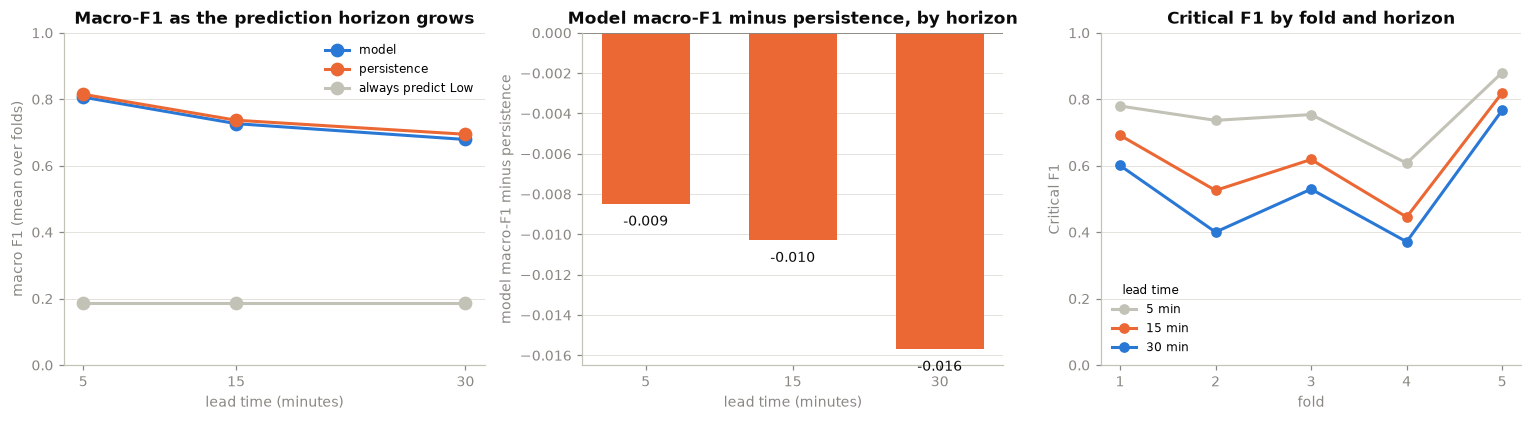

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
leads = sorted(combined.lead_min.unique())

# 1. Both approaches as the horizon grows.
axes[0].plot(leads, trend.model_macro_F1, marker="o", linewidth=2,
             markersize=8, color=BLUE, label="model")
axes[0].plot(leads, trend.persistence_macro_F1, marker="o", linewidth=2,
             markersize=8, color=ORANGE, label="persistence")
axes[0].plot(leads, trend.naive_macro_F1, marker="o", linewidth=2,
             markersize=8, color=GREY, label="always predict Low")
axes[0].set_xticks(leads)
axes[0].set_xlabel("lead time (minutes)")
axes[0].set_ylabel("macro F1 (mean over folds)")
axes[0].set_title("Macro-F1 as the prediction horizon grows")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, axis="y")

# 2. The gap itself - the headline.
gap_mean = trend.model_minus_persistence
colours = [BLUE if v > 0 else ORANGE for v in gap_mean]
axes[1].bar([str(l) for l in leads], gap_mean, color=colours, width=0.6)
axes[1].axhline(0, color=MUTED, linewidth=1.2)
for i, v in enumerate(gap_mean):
    axes[1].annotate(f"{v:+.3f}", xy=(i, v), xytext=(0, 6 if v > 0 else -14),
                     textcoords="offset points", ha="center",
                     fontsize=9, color=INK)
axes[1].set_xlabel("lead time (minutes)")
axes[1].set_ylabel("model macro-F1 minus persistence")
axes[1].set_title("Model macro-F1 minus persistence, by horizon")
axes[1].grid(True, axis="y")

# 3. Critical F1 - the class that matters for rerouting.
for lead, colour in zip(leads, [GREY, ORANGE, BLUE]):
    subset = combined[combined.lead_min == lead]
    axes[2].plot(subset.fold, subset.critical_F1, marker="o", linewidth=2,
                 markersize=6, color=colour, label=f"{lead} min")
axes[2].set_xlabel("fold")
axes[2].set_ylabel("Critical F1")
axes[2].set_title("Critical F1 by fold and horizon")
axes[2].set_xticks(sorted(combined.fold.unique()))
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=8, title="lead time", title_fontsize=8)
axes[2].grid(True, axis="y")

plt.tight_layout()
plt.show()

In [10]:
combined.to_csv(PROCESSED / "horizon_fold_scores.csv", index=False)
per_class.to_csv(PROCESSED / "horizon_per_class_scores.csv", index=False)
print("saved horizon_fold_scores.csv and horizon_per_class_scores.csv")

saved horizon_fold_scores.csv and horizon_per_class_scores.csv


## Step 6 — Findings

### First: the clock-feature bug was real, and it did not matter

Before trusting any of this, one defect had to be ruled out. The cyclical
hour-of-day and day-of-week features were originally taken from notebook 02,
where they describe each row's **own** timestamp. For a 15- or 30-minute horizon
the moment being predicted is 10 or 25 minutes later, so the model was being told
the wrong time of day — by an amount that *grows with the horizon*, which is
exactly the shape that could manufacture a widening gap by itself.

That is fixed above: the clock features are recomputed from the target timestamp.
The correction is not trivially small (`hour_sin` moves by 0.044 at 15 min and
0.109 at 30 min), but the effect on the result is:

| Lead time | Gap before the fix | Gap after the fix |
|---|---|---|
| 5 min | −0.0085 | −0.0085 *(unchanged by construction)* |
| 15 min | −0.0100 | **−0.0103** |
| 30 min | −0.0146 | **−0.0157** |

The gap moved by 0.0003–0.0011 macro-F1, and moved slightly *against* the model.
So the bug was worth fixing and is now fixed, but it explains none of the gap.
A 10–25 minute phase error on a 24-hour cycle is under 2% of the period; it was
always more likely to be a rounding-level effect than the cause. Now that is
measured rather than assumed.

### The hypothesis from notebook 05 was wrong

Notebook 05 proposed that the model lost to persistence because the task was
framed too easily, and predicted a longer horizon would let it overtake.
**It does not.** The model fails to beat persistence at every horizon tested, and
the gap *widens*:

| Lead time | Model macro-F1 | Persistence macro-F1 | Difference |
|---|---|---|---|
| 5 min | 0.8065 | 0.8150 | **−0.0085** |
| 15 min | 0.7268 | 0.7371 | **−0.0103** |
| 30 min | 0.6791 | 0.6948 | **−0.0157** |

Persistence does decay as predicted — 0.815 → 0.737 → 0.695. The trouble is the
model decays slightly *faster*: 0.807 → 0.727 → 0.679. Extending the horizon made
the problem harder for both and never opened the gap the diagnosis expected.

Across all 15 fold–horizon combinations the model wins **4**, and never by more
than **+0.012** macro-F1.

### The Critical class degrades sharply

The class that matters for rerouting suffers most. Mean Critical F1 across folds:
**0.752 → 0.620 → 0.534**. On fold 4 — the calm window with ~0.9% Critical — it
falls to **0.372** at 30 minutes.

So the 30-minute model is not merely *no better* than persistence; in absolute
terms it is a weak detector of exactly the events the project exists to
anticipate.

### Why, most likely

The model can see `lag_1`. It has **strictly more information than persistence**,
so it could in principle learn "copy the last class" and tie. Ending up
consistently behind means something is pushing it off that solution.

The per-fold pattern points at what:

| Fold | Character | Gap at 30 min |
|---|---|---|
| 1 | shortest training window, dominated by the April transfers | **−0.0557** |
| 4 | calmest, most routine test window | **+0.0117** |

The model does best where conditions are most ordinary and worst where the
training window is short and atypical. That is the signature of **train/test
distribution shift**, documented in notebooks 03 and 04. The model fits patterns
from its training window; when the test window holds a different traffic regime,
they transfer imperfectly. Persistence has nothing to transfer — it never learned
anything — so a changing regime costs it nothing.

A second contributor: the balanced class weighting deliberately moves the model
away from the plain-accuracy optimum to catch rare classes, while persistence is
unweighted. That is a trade we chose, and worth remembering when reading one
aggregate number.

*(Both are readings consistent with the evidence, not results we have isolated.
Testing the first would mean comparing train-set against test-set scores — a
diagnostic step, not a tuning step.)*

### What we are not doing

We are **not** adding features or tuning hyperparameters to turn this into a win.
The instruction for this step was to report the outcome plainly if the model still
lost at 30 minutes, and it did — after the one plausible confounder was found,
fixed, and shown to be immaterial.

**On this dataset, with per-link history and time-of-day features, a learned
classifier does not beat "assume nothing changed" at 5, 15 or 30 minutes ahead.**

### What that implies for the project

The finding narrows the options usefully rather than closing them off:

- **The features are the more likely limit, not the horizon.** Every feature here
  comes from a single link's own past plus the clock. Notebook 03 showed
  congestion travels along *paths* — adjacent corridor links correlate at 0.997,
  and 14% of timesteps have five or more links Critical at once, which suggests a
  model able to see *neighbouring* links might have information persistence
  cannot use.

  > **Superseded — see notebook 07.** This suggestion was tested and is wrong.
  > Consecutive links peak at **lag 0**: congestion does not propagate along a
  > path, the links light up simultaneously, because `link_loads(t) = demand(t)
  > @ A.T` and `A` has no time dimension. At a 15-minute lag only 1 link in 30
  > has any neighbour that beats its own history, by +0.0006. The 0.997
  > correlation is precisely *why* it fails — neighbours are redundant copies,
  > not early warnings.
- **The episodes are the hard part.** Both large transfers were driven by single
  OD pairs at 150–575× normal levels. Nothing in a link's own recent history
  anticipates that, which puts a real ceiling on any per-link model.
- **For the routing half of the project, persistence is a legitimate input.** If
  the best available congestion signal is "what it was five minutes ago",
  adaptive rerouting can still be built and evaluated on it — the routing
  contribution does not depend on the classifier winning.